In [2]:
from pathlib import Path

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt

from nbtools import auto_plot_style
from jupyfun import progressbar

%matplotlib inline
auto_plot_style()

In [3]:
path      = Path("/home/gonzalo/data/COLINA/mc/pcolina/survival_20260226_113008/")
filenames = sorted(path.glob("*.h5"))
len(filenames)

100

In [4]:
filename = filenames[3]
df = pd.read_hdf(filename, "/endpoints")
#df = pd.concat([pd.read_hdf(filename, "/endpoints") for filename in filenames], ignore_index=True)
df.insert(df.shape[1], "r0", (df.x0**2 + df.y0**2)**0.5)
df.insert(df.shape[1], "r1", (df.x1**2 + df.y1**2)**0.5)
df

,event,x0,y0,z0,x1,y1,z1,t,r0,r1
0,0,52.048512,74.115601,74.937080,51.486141,73.665894,73.854866,0.940000,90.565834,89.874840
1,1,-21.247013,-66.617722,102.336830,-2.068339,-6.050382,-0.018750,81.040001,69.923935,6.394149
2,2,-16.120504,-15.314486,84.191406,-2.292398,-1.941584,-0.026922,46.910000,22.235199,3.004137
3,3,-6.736191,30.472340,114.592026,-1.113755,3.611459,-0.003962,72.709999,31.208008,3.779297
4,4,-114.676559,-26.221136,111.725555,-128.442596,-31.727913,116.292931,72.839996,117.636139,132.303284
...,...,...,...,...,...,...,...,...,...,...
999995,999995,-6.042334,-76.444016,73.301369,-0.472635,-8.176537,-0.000517,60.629997,76.682442,8.190186
999996,999996,-80.605873,-40.663132,79.019051,-6.966995,-3.404877,-0.027552,75.769997,90.281761,7.754497
999997,999997,-68.900185,22.172039,117.279129,-6.323483,2.115063,-0.008536,100.639999,72.379791,6.667828
999998,999998,-69.838211,-18.531141,91.885948,-5.794925,-1.706348,-0.008939,72.639999,72.254959,6.040926


In [4]:
df.describe()

,event,x0,y0,z0,x1,y1,z1,t,r0,r1
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,499999.500000,0.011519,-0.050433,86.085579,0.046060,-0.029721,8.389569,74.484535,68.010567,15.844830
std,288675.278932,52.616425,52.667797,26.124321,24.838892,24.891838,28.815027,54.871037,30.319113,31.403908
min,0.000000,-135.593948,-135.353058,0.010758,-135.814133,-135.481613,-0.044367,0.020000,0.029312,0.034441
25%,249999.750000,-38.417668,-38.528425,69.660578,-4.636135,-4.641845,-0.020432,40.969997,44.438328,5.977898
50%,499999.500000,-0.028732,-0.033803,91.938705,-0.006482,-0.004848,-0.012737,64.739998,67.971806,7.219409
75%,749999.250000,38.445641,38.399214,107.554861,4.632637,4.638025,-0.005075,92.509995,91.483097,8.000247
max,999999.000000,135.320251,135.591263,119.999977,135.381226,135.622971,120.024635,778.289978,135.879257,135.942215


In [5]:
def compute_survival(df, zcut, rcut):
    reached_gate = (df.z1 > -zcut) & (df.r1 < (16-rcut))
    return pd.Series(dict( nevt  = len(df)
                         , ngate = np.count_nonzero(reached_gate)
                         ))

In [6]:
nbinsr = 100
nbinsz = 100
rbins = np.linspace(0, 136, nbinsr+1)
zbins = np.linspace(0, 120, nbinsz+1)
bin_width_r = np.diff(rbins)[0]
bin_width_z = np.diff(zbins)[0]
form_factor = 1

indices = np.meshgrid( np.arange(nbinsr)
                     , np.arange(nbinsz)
                     , indexing="ij")
indices = np.array(list(zip(*map(np.ravel, indices)))).T
empty_survival_map = pd.DataFrame(dict(rbin=indices[0], zbin=indices[1], nevt=0, ngate=0))
empty_survival_map

,rbin,zbin,nevt,ngate
0,0,0,0,0
1,0,1,0,0
2,0,2,0,0
3,0,3,0,0
4,0,4,0,0
...,...,...,...,...
9995,99,95,0,0
9996,99,96,0,0
9997,99,97,0,0
9998,99,98,0,0


In [7]:
zcut = 0.05 # mm
rcut = 0.10 # mm
r_el = 16

dfs = []
for filename in progressbar(filenames):
    df = pd.read_hdf(filename, "/endpoints")
    df.insert(df.shape[1], "r0", (df.x0**2 + df.y0**2)**0.5)
    df.insert(df.shape[1], "r1", (df.x1**2 + df.y1**2)**0.5)

    df = ( df.assign( rbin = lambda df: np.clip(np.digitize(df.r0, rbins)-1, 0, nbinsr-1)
                    , zbin = lambda df: np.clip(np.digitize(df.z0, zbins)-1, 0, nbinsz-1))
             .groupby("rbin zbin".split())
             .apply(compute_survival, zcut, rcut, include_groups=False)
             .reset_index()
         )
    dfs.append(df)

dfs = pd.concat(dfs + [empty_survival_map], ignore_index=True)
dfs = dfs.groupby("rbin zbin".split()).sum().reset_index()
#dfs = ( pd.concat([dfs, empty_survival_map], ignore_index=True)
#               .groupby("rbin zbin".split())
#               .first()
#               .reset_index())

dfs.insert(dfs.shape[1], "r"     , (dfs.rbin + 0.5) * bin_width_r)
dfs.insert(dfs.shape[1], "z"     , (dfs.zbin + 0.5) * bin_width_z)
dfs.insert(dfs.shape[1], "out"   , (dfs.r - r_el) / dfs.z > 1)
dfs.insert(dfs.shape[1], "prob"  , dfs.ngate / np.clip(dfs.nevt, 1, None))
dfs.insert(dfs.shape[1], "binvol", 2 * np.pi * dfs.r * bin_width_r * bin_width_z)
dfs.insert(dfs.shape[1], "effvol", dfs.binvol * dfs.prob)

survival = dfs

Item 100 of 100 | 1.04 s/item | ETA 0.0 min | Ellapsed 1.7 min


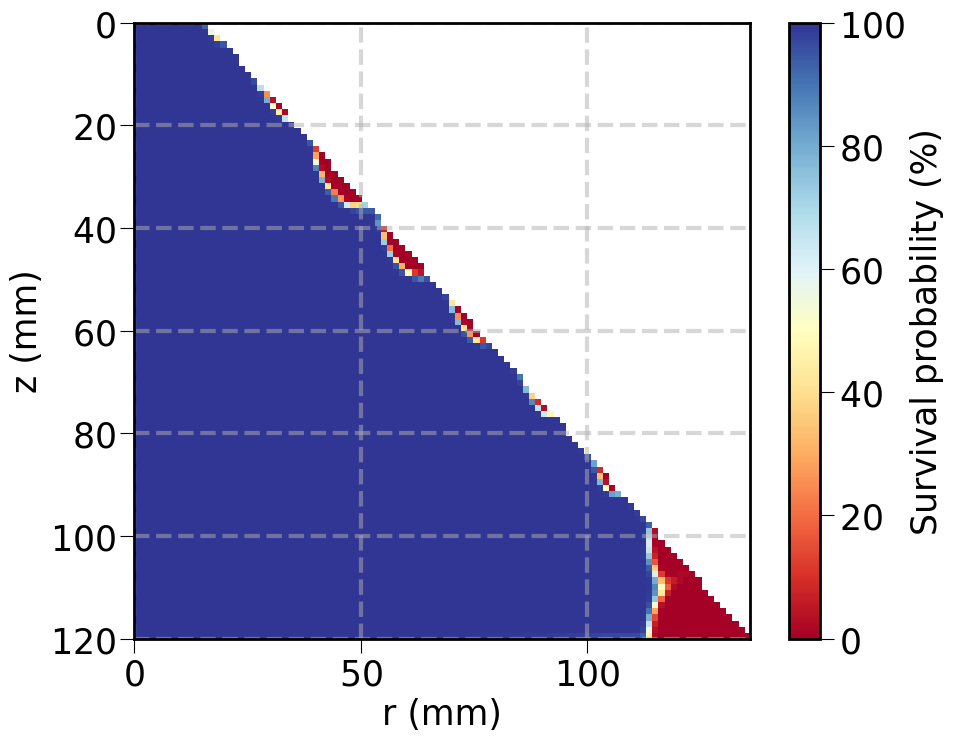

In [10]:
sp  = np.where(survival.out, np.nan, survival.prob.values)
sp  = sp.reshape(nbinsr, nbinsz)
sp  = sp * 100

extent = (rbins.min(), rbins.max(), zbins.min(), zbins.max())

plt.imshow(sp.T, origin="lower", extent=extent, aspect=136/120, cmap="RdYlBu")
plt.gca().invert_yaxis()
plt.colorbar().set_label("Survival probability (%)")
plt.xlabel("r (mm)")
plt.ylabel("z (mm)")
plt.grid()

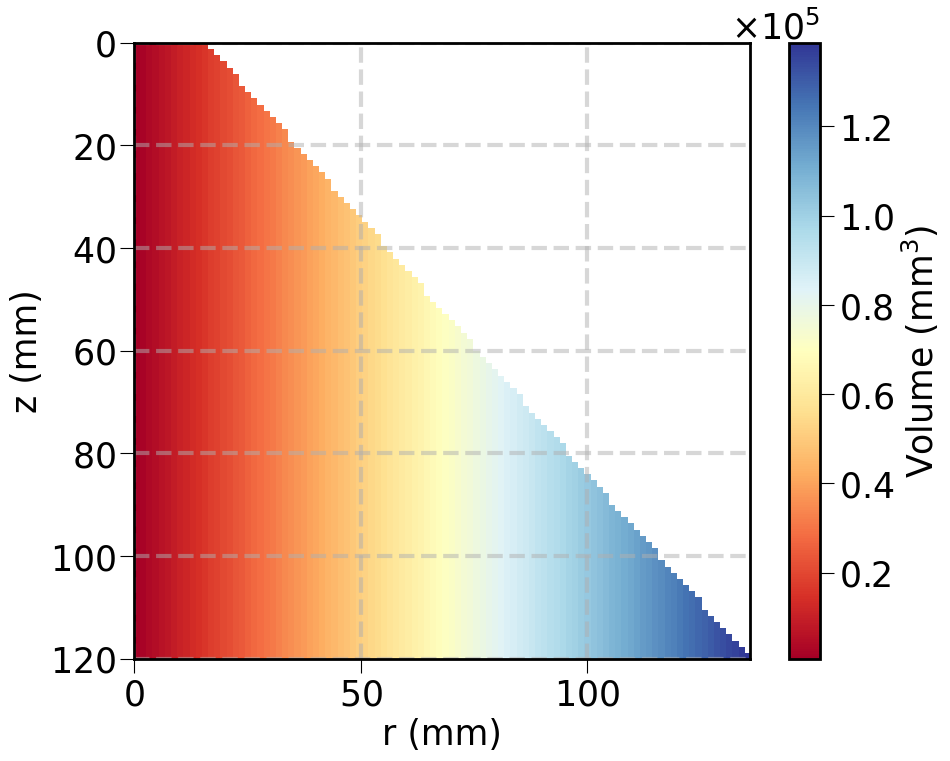

In [11]:
sp  = np.where(survival.out, np.nan, survival.binvol.values)
sp  = sp.reshape(nbinsr, nbinsz)
sp  = sp * 100

extent = (rbins.min(), rbins.max(), zbins.min(), zbins.max())

plt.imshow(sp.T, origin="lower", extent=extent, aspect=136/120, cmap="RdYlBu")
plt.gca().invert_yaxis()
plt.colorbar().set_label("Volume (mm$^3$)")
plt.xlabel("r (mm)")
plt.ylabel("z (mm)")
plt.grid()

In [17]:
total_vol = survival[~survival.out.values].binvol.sum()/1e6
total_vol

2.629474254144677

In [18]:
total_vol_analytical = np.pi/3/form_factor*(136**3-16**3)/1e6
total_vol_analytical

2.6298900421730877

In [19]:
eff_vol = survival[~survival.out.values].effvol.sum()/1e6
eff_vol, eff_vol/total_vol

(2.407731978740527, 0.9156704900020863)